# Task 2: Linear and Polynomial Regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## (a) Closed-form linear regression

In [2]:
# Load x and y. We add a column of 1s to x so the model also has a bias term.
x = np.loadtxt('hw1x.dat')
y = np.loadtxt('hw1y.dat')

X = np.column_stack([np.ones(len(x)), x])
print('X shape:', X.shape, ' y shape:', y.shape)

X shape: (200, 2)  y shape: (200,)


In [3]:
def linear_regression(X, y):
    # Closed-form solution of the normal equations:
    #   theta = (X^T X)^(-1) X^T y
    return np.linalg.inv(X.T @ X) @ X.T @ y


def mse(X, y, theta):
    # mean squared error
    preds = X @ theta
    return np.mean((preds - y) ** 2)


theta_cf = linear_regression(X, y)
print('theta (bias, slope):', np.round(theta_cf, 4))
print('training MSE:', round(mse(X, y, theta_cf), 4))

theta (bias, slope): [3.2447 1.7816]
training MSE: 1.1625


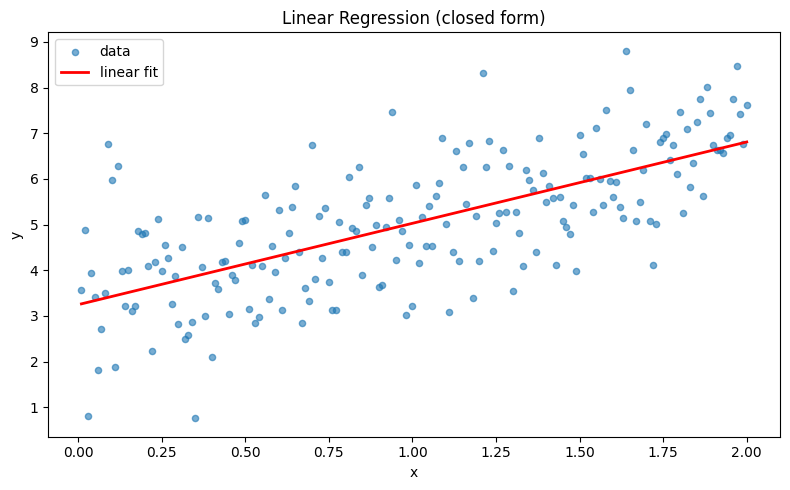

In [4]:
# plot the data and the fitted line
x_line = np.linspace(x.min(), x.max(), 200)
y_line = theta_cf[0] + theta_cf[1] * x_line

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=20, alpha=0.6, label='data')
plt.plot(x_line, y_line, 'r', linewidth=2, label='linear fit')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Linear Regression (closed form)')
plt.legend()
plt.tight_layout()
plt.savefig('linear_regression.png', dpi=100)
plt.show()

## (b) Gradient descent and stochastic gradient descent

In [5]:
def gradient_descent(X, y, eta=0.01, epochs=5):
    # Batch gradient descent: one update per epoch using all the data.
    n = len(y)
    theta = np.zeros(X.shape[1])
    errors = []
    for e in range(epochs):
        grad = X.T @ (X @ theta - y) / n
        theta = theta - eta * grad
        errors.append(mse(X, y, theta))
    return theta, errors


theta_gd, errors_gd = gradient_descent(X, y)
print('Batch GD final theta:', np.round(theta_gd, 4))
print('MSE per epoch:', [round(e, 4) for e in errors_gd])

Batch GD final theta: [0.2413 0.2703]
MSE per epoch: [np.float64(26.4398), np.float64(25.355), np.float64(24.3172), np.float64(23.3244), np.float64(22.3745)]


In [6]:
def stochastic_gradient_descent(X, y, eta=0.01, epochs=5):
    # SGD: one update per data point. We shuffle the order each epoch.
    np.random.seed(0)
    n = len(y)
    theta = np.zeros(X.shape[1])
    errors = []
    for e in range(epochs):
        order = np.random.permutation(n)
        for i in order:
            grad = X[i] * (X[i] @ theta - y[i])
            theta = theta - eta * grad
        errors.append(mse(X, y, theta))
    return theta, errors


theta_sgd, errors_sgd = stochastic_gradient_descent(X, y)
print('SGD final theta:', np.round(theta_sgd, 4))
print('MSE per epoch:', [round(e, 4) for e in errors_sgd])

SGD final theta:

 [3.0091 1.9637]
MSE per epoch: [np.float64(1.3487), np.float64(1.2488), np.float64(1.209), np.float64(1.2157), np.float64(1.1763)]


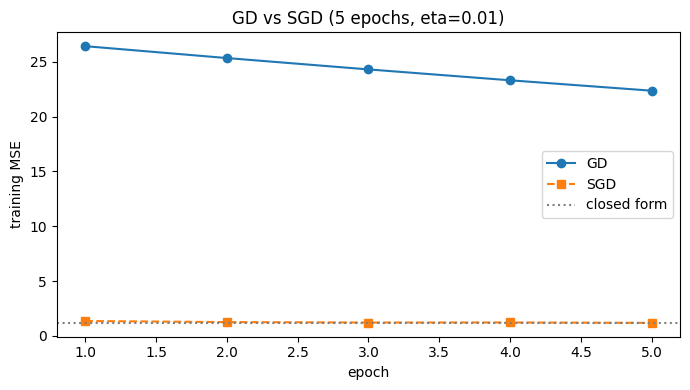

In [7]:
# compare how fast the two methods bring the error down
epochs = range(1, 6)
plt.figure(figsize=(7, 4))
plt.plot(epochs, errors_gd, 'o-', label='GD')
plt.plot(epochs, errors_sgd, 's--', label='SGD')
plt.axhline(mse(X, y, theta_cf), color='gray', linestyle=':', label='closed form')
plt.xlabel('epoch'); plt.ylabel('training MSE')
plt.title('GD vs SGD (5 epochs, eta=0.01)')
plt.legend()
plt.tight_layout()
plt.savefig('gd_convergence.png', dpi=100)
plt.show()

## (c) Polynomial regression

degree-2 theta: [3.5808 0.7834 0.4966]
degree-2 MSE: 1.1406


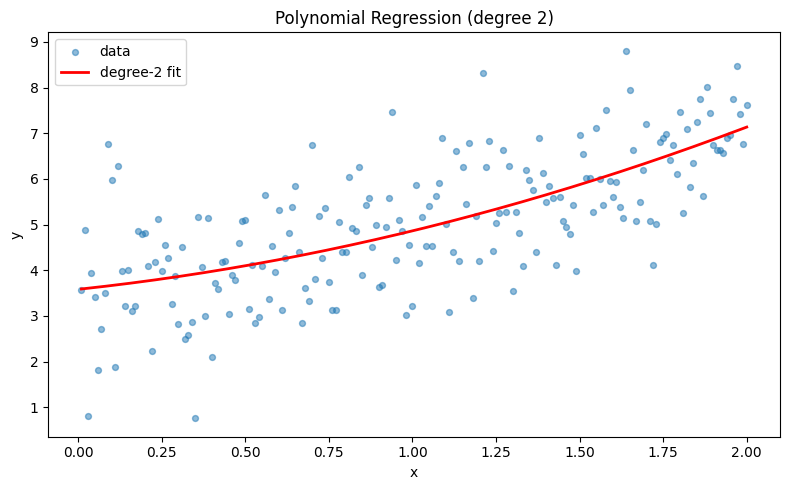

In [8]:
def PolyRegress(x, y, d):
    # Fit a polynomial of degree d.
    # Build the design matrix [1, x, x^2, ..., x^d] one column at a time,
    # then reuse the closed-form linear regression from part (a).
    columns = []
    for k in range(d + 1):
        columns.append(x ** k)
    X_poly = np.column_stack(columns)
    theta = linear_regression(X_poly, y)
    error = mse(X_poly, y, theta)
    return theta, error


def poly_predict(theta, x):
    # evaluate the polynomial with coefficients theta at the points x
    result = np.zeros_like(x)
    for k in range(len(theta)):
        result = result + theta[k] * x ** k
    return result


# degree-2 fit
theta2, mse2 = PolyRegress(x, y, 2)
print('degree-2 theta:', np.round(theta2, 4))
print('degree-2 MSE:', round(mse2, 4))

x_line = np.linspace(x.min(), x.max(), 300)
plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=18, alpha=0.5, label='data')
plt.plot(x_line, poly_predict(theta2, x_line), 'r', linewidth=2, label='degree-2 fit')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Polynomial Regression (degree 2)')
plt.legend()
plt.tight_layout()
plt.savefig('poly_degree2.png', dpi=100)
plt.show()

In [9]:
# fit degrees 1 to 15 and record the training error
degrees = list(range(1, 16))
mse_list = []
theta_list = []
for d in degrees:
    theta_d, mse_d = PolyRegress(x, y, d)
    theta_list.append(theta_d)
    mse_list.append(mse_d)
    print('degree', d, '-> MSE', round(mse_d, 4))

degree 1 -> MSE 1.1625
degree 2 -> MSE 1.1406
degree 3 -> MSE 1.1402
degree 4 -> MSE 1.1292
degree 5 -> MSE 1.1278
degree 6 -> MSE 1.1227
degree 7 -> MSE 1.1125
degree 8 -> MSE 1.1076
degree 9 -> MSE 1.1058
degree 10 -> MSE 1.1052
degree 11 -> MSE 1.4402
degree 12 -> MSE 6.4399
degree 13 -> MSE 9.3212
degree 14 -> MSE 5.7676
degree 15 -> MSE 100.5221


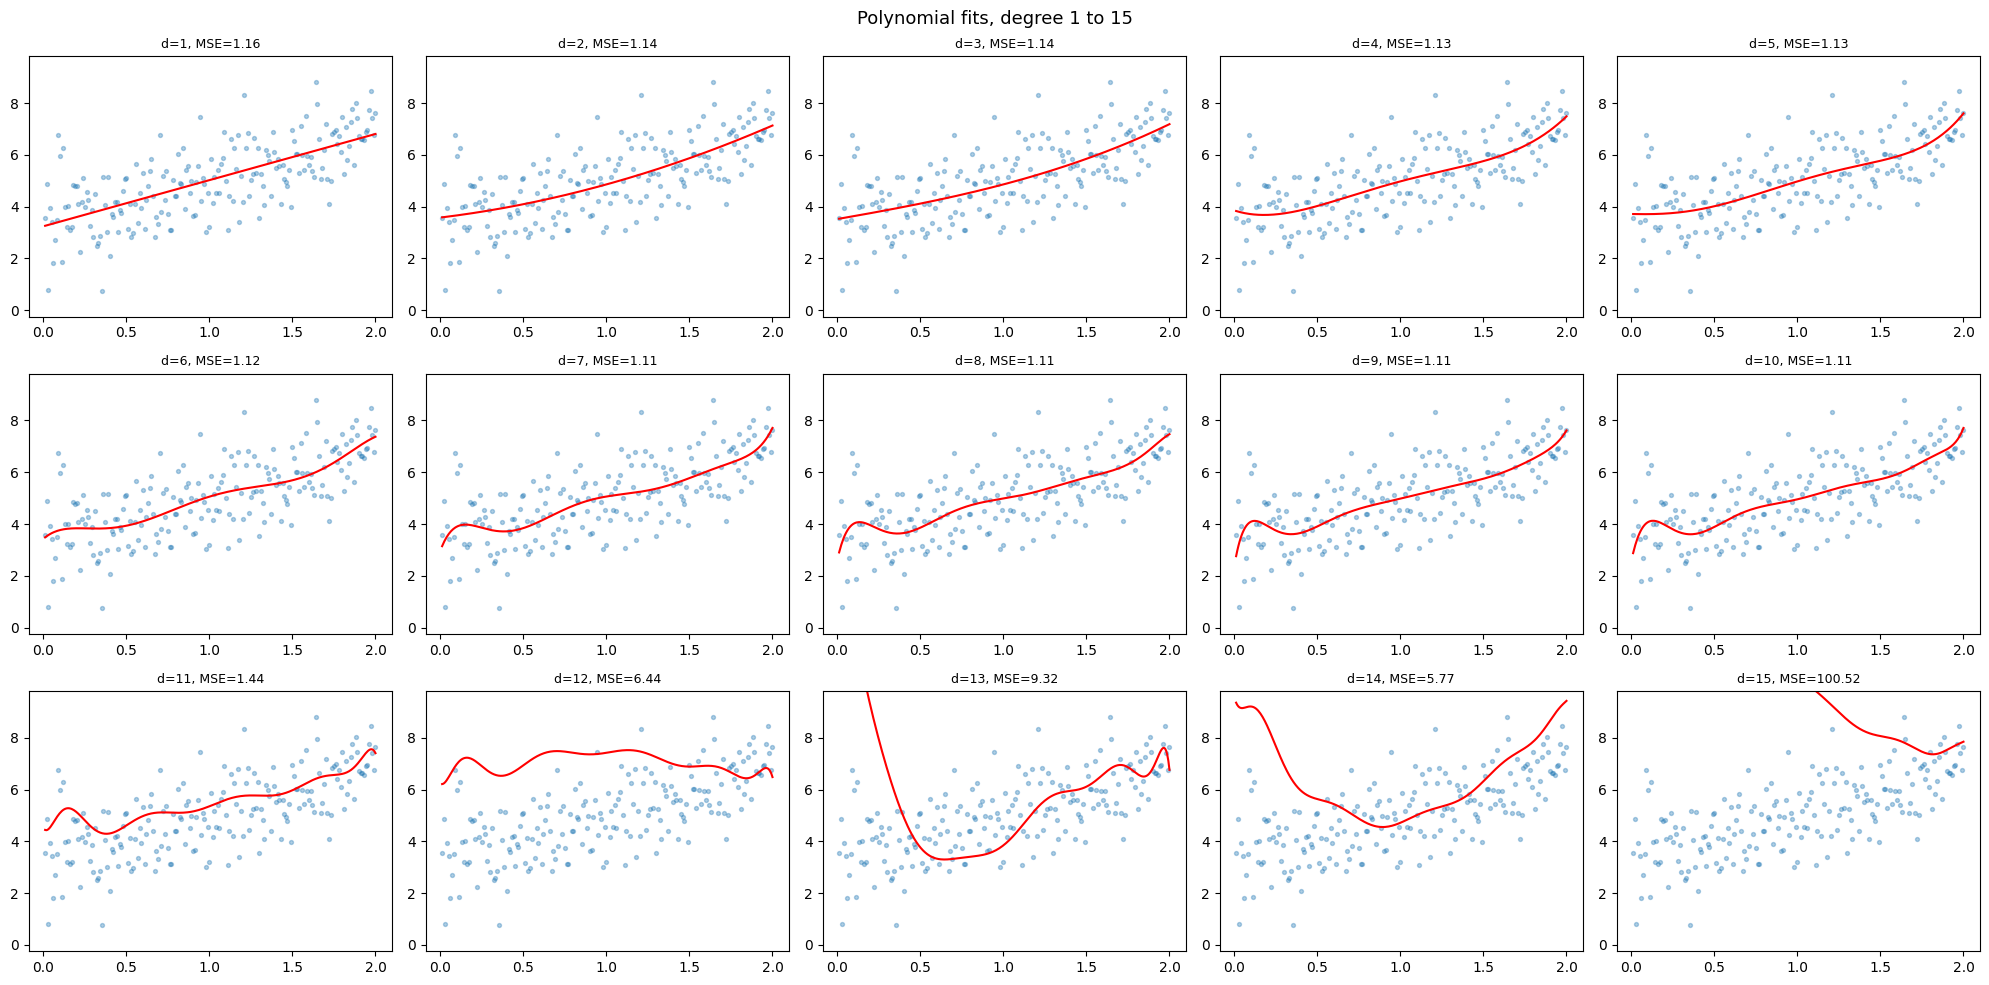

In [10]:
# show all 15 fits in a grid
fig, axes = plt.subplots(3, 5, figsize=(20, 10))
axes = axes.flatten()
for i in range(len(degrees)):
    d = degrees[i]
    theta_d = theta_list[i]
    ax = axes[i]
    ax.scatter(x, y, s=8, alpha=0.35)
    ax.plot(x_line, poly_predict(theta_d, x_line), 'r', linewidth=1.5)
    ax.set_ylim(y.min() - 1, y.max() + 1)
    ax.set_title('d=' + str(d) + ', MSE=' + str(round(mse_list[i], 2)), fontsize=9)
plt.suptitle('Polynomial fits, degree 1 to 15', fontsize=13)
plt.tight_layout()
plt.savefig('poly_all_degrees.png', dpi=100)
plt.show()

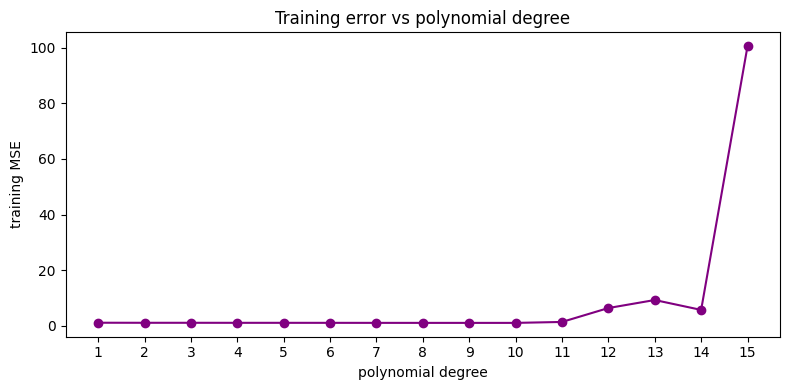

error first goes up at degree 11 : 1.1052 -> 1.4402


In [11]:
# training error vs degree
plt.figure(figsize=(8, 4))
plt.plot(degrees, mse_list, 'o-', color='purple')
plt.xlabel('polynomial degree'); plt.ylabel('training MSE')
plt.title('Training error vs polynomial degree')
plt.xticks(degrees)
plt.tight_layout()
plt.savefig('poly_error_vs_degree.png', dpi=100)
plt.show()

# find the first degree where the error went up instead of down
for i in range(1, len(mse_list)):
    if mse_list[i] > mse_list[i - 1]:
        print('error first goes up at degree', degrees[i],
              ':', round(mse_list[i - 1], 4), '->', round(mse_list[i], 4))
        break

**Note on the high degrees.** In theory the training error should never go up
when we add more polynomial terms. But here it does once the degree gets large.
The reason is numerical: the columns `x`, `x^2`, ..., `x^15` become very similar
in size and direction, so `X^T X` is almost singular (ill-conditioned) and
`np.linalg.inv` can no longer solve it accurately. The big jumps in MSE at the
high degrees come from this, not from a real worse fit. A more numerically stable
way to solve the same equations is `np.linalg.lstsq` (or `np.linalg.pinv`), which
would keep the error flat instead of blowing up.